**Análisis exploratorio de los datos, visualizaciones y detección de patrones.**

In [1]:
# Importe de librerías necesarias
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/ramirezluna-david/proyecto_modelado_grp2/rama_david/data/dataset_clientes_limpio.csv"

In [3]:
# Lectura de datos del dataset
data = pd.read_csv(url)
data.head()

,ratio_endeudamiento,porcentaje_gasto,gasto_mensual,score_crediticio,ingreso_mensual,deuda_total,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,abandono
0,-0.087339,8.917517e-02,0.928655,-1.616594,5.299850e-01,0.572683,0.995847,1.213020,-0.724598,1.589155,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,-1.135785,-1.246435e+00,-0.634528,-0.283686,1.882364e+00,-0.532574,0.141534,0.142729,-0.358339,1.202924,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0
2,0.000000,4.360560e-16,-0.091194,1.852509,5.168572e-16,1.849046,-0.029329,-1.581629,0.374180,0.478739,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0
3,2.483183,1.613845e+00,0.133315,-1.757904,-1.633970e+00,1.308836,0.312397,-1.581629,-1.273987,-0.168199,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1
4,-0.398030,4.649992e-01,0.681864,-1.474195,-2.844893e-01,-0.509680,-0.997550,-1.373516,-0.907728,0.971185,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1


# Análisis de tipo de dato

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ratio_endeudamiento            20000 non-null  float64
 1   porcentaje_gasto               20000 non-null  float64
 2   gasto_mensual                  20000 non-null  float64
 3   score_crediticio               20000 non-null  float64
 4   ingreso_mensual                20000 non-null  float64
 5   deuda_total                    20000 non-null  float64
 6   edad                           20000 non-null  float64
 7   antiguedad_meses               20000 non-null  float64
 8   frecuencia_compra              20000 non-null  float64
 9   ultima_compra_dias             20000 non-null  float64
 10  num_productos                  20000 non-null  float64
 11  hora_registro                  20000 non-null  float64
 12  tiene_tarjeta_credito_0        20000 non-null  float64
 1

# Variables para modelos de regresión

## Objetivo: "deuda_total"

In [5]:
target = "deuda_total"

In [6]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

deuda_total                      1.000000
ratio_endeudamiento              0.686955
abandono                         0.032325
num_productos                    0.013772
porcentaje_gasto                 0.010858
dia_semana_registro_Jueves       0.010401
dia_semana_registro_Miercoles    0.007948
canal_registro_Web               0.007834
genero_Otro                      0.007652
gasto_mensual                    0.006583
dia_semana_registro_Martes       0.005612
frecuencia_compra                0.005478
antiguedad_meses                 0.005386
estado_civil_Divorciado          0.004262
region_Norte                     0.003756
region_Sur                       0.002802
estado_civil_Soltero             0.002311
score_crediticio                 0.002102
edad                             0.001181
genero_Femenino                  0.000437
tiene_tarjeta_credito_1          0.000417
dia_semana_registro_Sabado       0.000254
tipo_plan                        0.000197
tiene_tarjeta_credito_0         -0

In [7]:
# Calcula la matriz de correlaciones (sólo valores numéricos)
numerical_features = ["deuda_total", "ratio_endeudamiento", "porcentaje_gasto", "gasto_mensual", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas
correlaciones = data[numerical_features].corr(method="pearson")

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

deuda_total            1.000000
ratio_endeudamiento    0.686955
num_productos          0.013772
porcentaje_gasto       0.010858
gasto_mensual          0.006583
frecuencia_compra      0.005478
antiguedad_meses       0.005386
score_crediticio       0.002102
edad                   0.001181
ultima_compra_dias    -0.006119
ingreso_mensual       -0.006251
hora_registro         -0.010741
Name: deuda_total, dtype: float64

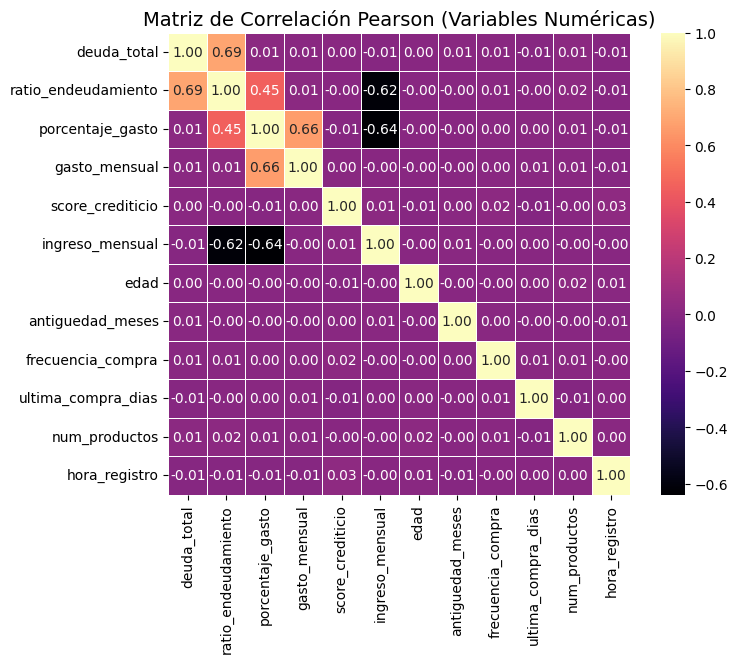

In [8]:
# heatmap matriz de correlación
plt.figure(figsize=(8, 6))  # tamaño de la figura
sns.heatmap(
    correlaciones,
    annot=True,       # mostrar los valores
    cmap="magma",     # paleta de colores
    fmt=".2f",        # formato decimal
    square=True,      # cuadrados uniformes
    linewidths=0.5    # líneas entre celdas
)
plt.title("Matriz de Correlación Pearson (Variables Numéricas)", fontsize=14)
plt.show()

In [9]:
# Calcula la matriz de correlaciones Spearman (sólo valores numéricos)
correlaciones_spearman = data[numerical_features].corr(method="spearman")

# Ver correlación con la variable objetivo
correlacion_objetivo_spearman = correlaciones_spearman[target].sort_values(ascending=False)

correlacion_objetivo_spearman

deuda_total            1.000000
ratio_endeudamiento    0.734316
num_productos          0.013604
porcentaje_gasto       0.008665
antiguedad_meses       0.006116
frecuencia_compra      0.005897
gasto_mensual          0.003578
score_crediticio       0.002800
edad                   0.001206
ingreso_mensual       -0.004882
ultima_compra_dias    -0.005383
hora_registro         -0.010655
Name: deuda_total, dtype: float64

In [10]:
variables_discretas = [
    "deuda_total",
    "tiene_tarjeta_credito_0",
    "tiene_tarjeta_credito_1",
    "genero_Femenino",
    "genero_Masculino",
    "genero_Otro",
    "region_Centro",
    "region_Norte",
    "region_Sur",
    "estado_civil_Casado",
    "estado_civil_Divorciado",
    "estado_civil_Soltero",
    "canal_registro_App",
    "canal_registro_Tienda",
    "canal_registro_Web",
    "dia_semana_registro_Domingo",
    "dia_semana_registro_Jueves",
    "dia_semana_registro_Lunes",
    "dia_semana_registro_Martes",
    "dia_semana_registro_Miercoles",
    "dia_semana_registro_Sabado",
    "dia_semana_registro_Viernes",
    "tipo_plan",
    "uso_app",
    "abandono"
]

In [11]:
# matriz de correlacion de spearman sólo con variables discretas
correlaciones_spearman = data[variables_discretas].corr(method='spearman')
correlaciones_spearman[target].sort_values(ascending=False)
correlaciones_spearman


,deuda_total,tiene_tarjeta_credito_0,tiene_tarjeta_credito_1,genero_Femenino,genero_Masculino,genero_Otro,region_Centro,region_Norte,region_Sur,estado_civil_Casado,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,abandono
deuda_total,1.000000,-0.000593,0.000593,0.000390,-0.008134,0.007646,-0.006413,0.003423,0.002986,-0.007102,...,-0.003129,0.009087,-0.012054,0.005803,0.008335,0.000970,-0.009158,0.000899,-0.003299,0.032298
tiene_tarjeta_credito_0,-0.000593,1.000000,-1.000000,-0.004506,0.001326,0.003157,0.005481,-0.001413,-0.004063,0.002195,...,-0.010522,0.000797,0.001225,-0.004054,0.006316,-0.000650,0.006821,0.005512,0.012871,0.000173
tiene_tarjeta_credito_1,0.000593,-1.000000,1.000000,0.004506,-0.001326,-0.003157,-0.005481,0.001413,0.004063,-0.002195,...,0.010522,-0.000797,-0.001225,0.004054,-0.006316,0.000650,-0.006821,-0.005512,-0.012871,-0.000173
genero_Femenino,0.000390,-0.004506,0.004506,1.000000,-0.489248,-0.508237,0.000344,0.000427,-0.000771,-0.014113,...,-0.004621,-0.000643,-0.004389,0.004815,-0.000090,0.010121,-0.005148,0.009017,-0.013391,-0.004535
genero_Masculino,-0.008134,0.001326,-0.001326,-0.489248,1.000000,-0.502453,0.002292,-0.006882,0.004591,0.013140,...,0.006466,0.002848,0.002129,-0.006588,0.001362,-0.009457,0.003184,-0.003475,0.009435,-0.001049
genero_Otro,0.007646,0.003157,-0.003157,-0.508237,-0.502453,1.000000,-0.002604,0.006373,-0.003770,0.001015,...,-0.001804,-0.002175,0.002249,0.001732,-0.001255,-0.000694,0.001959,-0.005507,0.003958,0.005531
region_Centro,-0.006413,0.005481,-0.005481,0.000344,0.002292,-0.002604,1.000000,-0.499419,-0.499812,0.004402,...,-0.009037,0.001906,-0.000013,0.003117,-0.000298,0.000484,0.003838,-0.011148,0.008411,0.005515
region_Norte,0.003423,-0.001413,0.001413,0.000427,-0.006882,0.006373,-0.499419,1.000000,-0.500769,-0.005643,...,0.005123,-0.003978,0.004096,-0.010031,-0.006142,0.006782,0.004321,-0.001479,0.000654,-0.016328
region_Sur,0.002986,-0.004063,0.004063,-0.000771,0.004591,-0.003770,-0.499812,-0.500769,1.000000,0.001244,...,0.003908,0.002073,-0.004081,0.006914,0.006438,-0.007263,-0.008154,0.012617,-0.009056,0.010814
estado_civil_Casado,-0.007102,0.002195,-0.002195,-0.014113,0.013140,0.001015,0.004402,-0.005643,0.001244,1.000000,...,0.006469,0.005220,-0.016957,0.004918,-0.007540,-0.003749,0.011758,-0.011293,0.015139,-0.003035


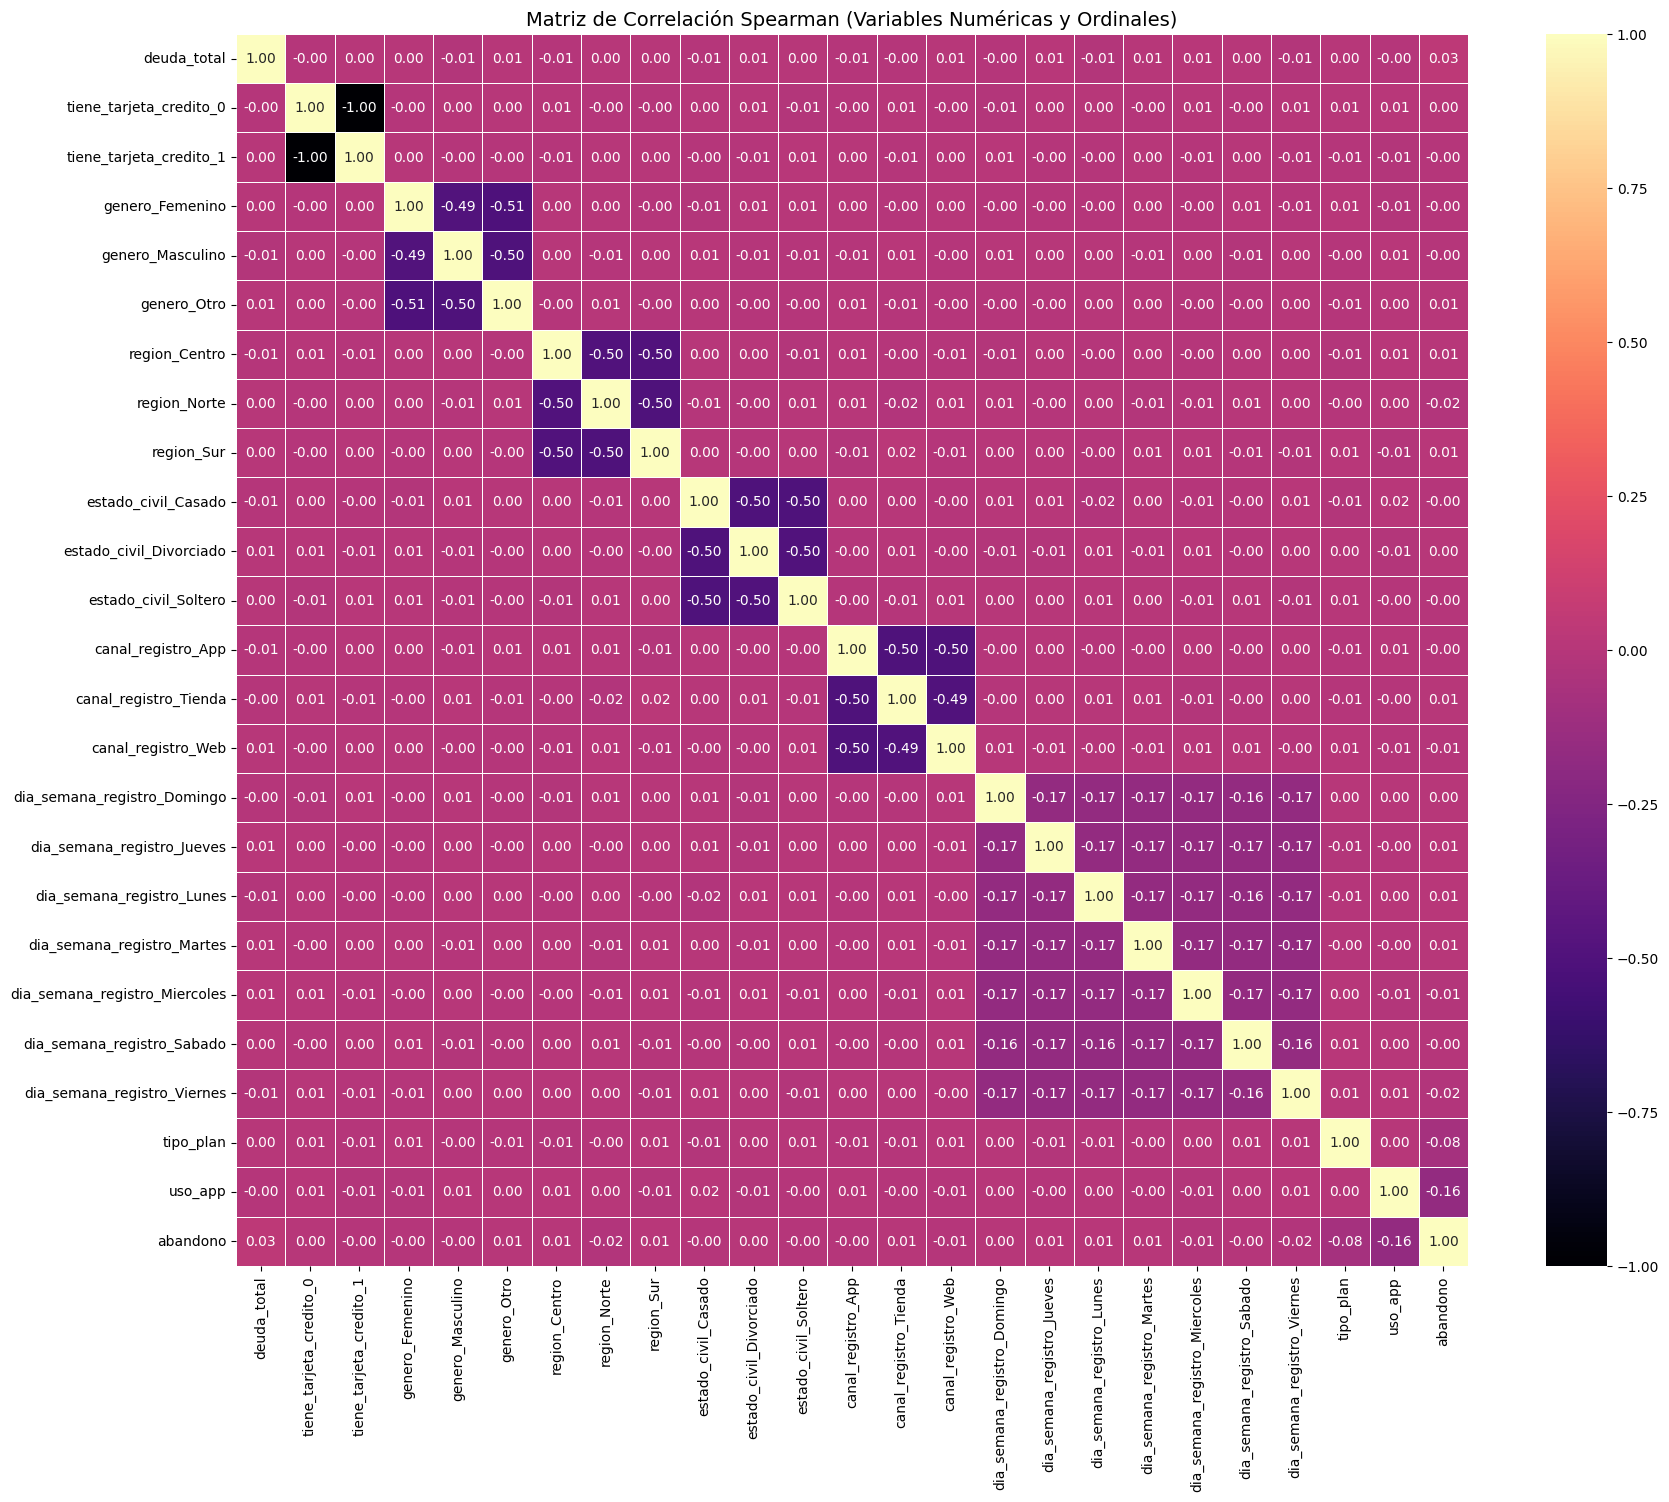

In [12]:
# graficar heatmap
plt.figure(figsize=(20, 16))  # tamaño de la figura
sns.heatmap(
    correlaciones_spearman,
    annot=True,       # mostrar los valores
    cmap="magma",  # paleta de colores
    fmt=".2f",        # formato decimal
    square=True,      # cuadrados uniformes
    linewidths=0.5    # líneas entre celdas
)
plt.title("Matriz de Correlación Spearman (Variables Numéricas y Ordinales)", fontsize=14)
plt.show()

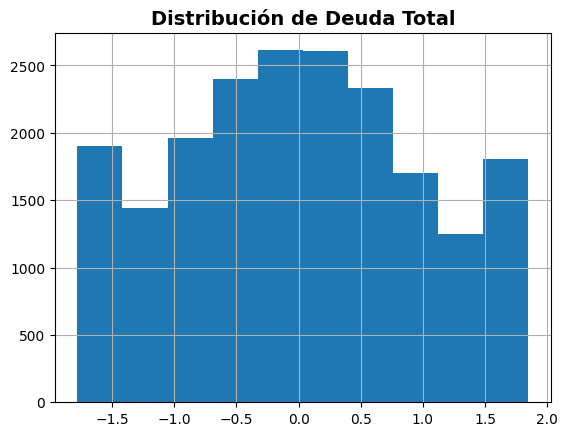

In [13]:
data["deuda_total"].hist()
plt.title("Distribución de Deuda Total", fontsize=14, fontweight="bold")
plt.show()

#### Mejores variables predictoras para los modelo de regresión lineal

In [14]:
def seleccionar_mejores_predictores(dataframe, target, umbral=0.008, incluir_objetivo=False):
    """
    Selecciona variables predictoras usando la matriz de correlaciones de Pearson.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Conjunto de datos con variables numericas.
    target : str
        Nombre de la variable objetivo.
    umbral : float, default=0.008
        Umbral minimo de correlacion (valor absoluto).
    incluir_objetivo : bool, default=False
        Si True, mantiene la variable objetivo en el resultado.

    Returns
    -------
    pd.DataFrame
        Tabla con variables y correlaciones ordenadas.
    """
    correlaciones = dataframe.corr(numeric_only=True)
    correlacion_objetivo = correlaciones[target].sort_values(ascending=False)
    correlacion_abs = correlacion_objetivo.abs()
    mask = correlacion_abs >= umbral
    if not incluir_objetivo:
        mask = mask & (correlacion_abs < 1.0)
    seleccion = correlacion_objetivo[mask].sort_values(ascending=False)
    salida = seleccion.reset_index()
    salida.columns = ["variable", "correlacion"]
    salida["correlacion_abs"] = salida["correlacion"].abs()
    salida = salida.sort_values("correlacion_abs", ascending=False).reset_index(drop=True)
    salida.index = salida.index + 1
    salida.index.name = "ranking"
    return salida

mejores_predictores = seleccionar_mejores_predictores(
    data,
    target,
    umbral=0.008,
 )
mejores_predictores.round(4)

,variable,correlacion,correlacion_abs
ranking,,,
1,ratio_endeudamiento,0.6870,0.6870
2,abandono,0.0323,0.0323
3,num_productos,0.0138,0.0138
4,dia_semana_registro_Lunes,-0.0121,0.0121
5,porcentaje_gasto,0.0109,0.0109
6,hora_registro,-0.0107,0.0107
7,dia_semana_registro_Jueves,0.0104,0.0104
8,dia_semana_registro_Viernes,-0.0088,0.0088
9,genero_Masculino,-0.0082,0.0082


### Variable para modelos de clasificación

In [15]:
target = "abandono"

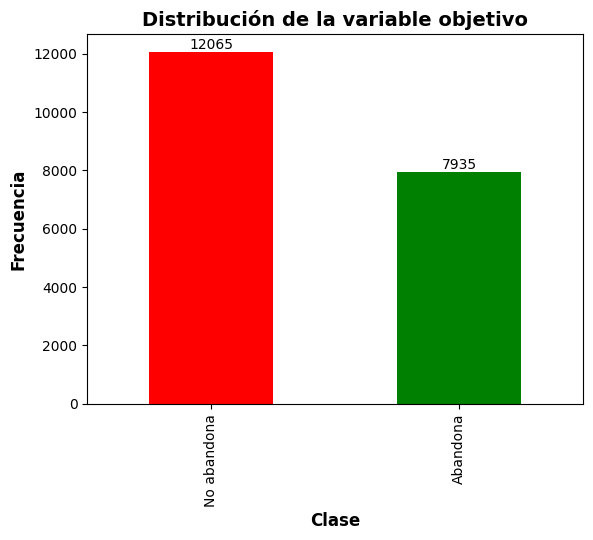

In [16]:
# grafica la distribución de la variable objetivo
data[target].value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Distribución de la variable objetivo", fontweight="bold", fontsize=14)
plt.xlabel("Clase", fontweight="bold", fontsize=12)
plt.ylabel("Frecuencia", fontweight="bold", fontsize=12)
# agrega los nombres de las clases en el eje (0 = No, 1 = Si)
plt.xticks([0, 1], ["No abandona", "Abandona"])
# Agrega las etiquetas a cada clase
for i, count in enumerate(data[target].value_counts()):
    plt.text(i, count, str(count), ha="center", va="bottom")
plt.show()

In [17]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

abandono                         1.000000
ultima_compra_dias               0.212568
deuda_total                      0.032325
ratio_endeudamiento              0.019814
dia_semana_registro_Jueves       0.012692
region_Sur                       0.010814
dia_semana_registro_Lunes        0.008319
dia_semana_registro_Martes       0.007734
hora_registro                    0.007570
canal_registro_Tienda            0.007372
edad                             0.006443
genero_Otro                      0.005531
region_Centro                    0.005515
estado_civil_Divorciado          0.004422
ingreso_mensual                  0.003754
dia_semana_registro_Domingo      0.001531
tiene_tarjeta_credito_0          0.000173
tiene_tarjeta_credito_1         -0.000173
canal_registro_App              -0.000696
genero_Masculino                -0.001049
estado_civil_Soltero            -0.001378
num_productos                   -0.002758
estado_civil_Casado             -0.003035
dia_semana_registro_Sabado      -0

In [18]:
# Calcula la matriz de correlaciones (sólo valores numéricos)
numerical_features = ["abandono", "ratio_endeudamiento", "porcentaje_gasto", "gasto_mensual", "score_crediticio", "ingreso_mensual", "deuda_total", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas
correlaciones = data[numerical_features].corr(method="pearson")

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

abandono               1.000000
ultima_compra_dias     0.212568
deuda_total            0.032325
ratio_endeudamiento    0.019814
hora_registro          0.007570
edad                   0.006443
ingreso_mensual        0.003754
num_productos         -0.002758
antiguedad_meses      -0.006374
porcentaje_gasto      -0.007265
gasto_mensual         -0.010374
score_crediticio      -0.026656
frecuencia_compra     -0.044897
Name: abandono, dtype: float64

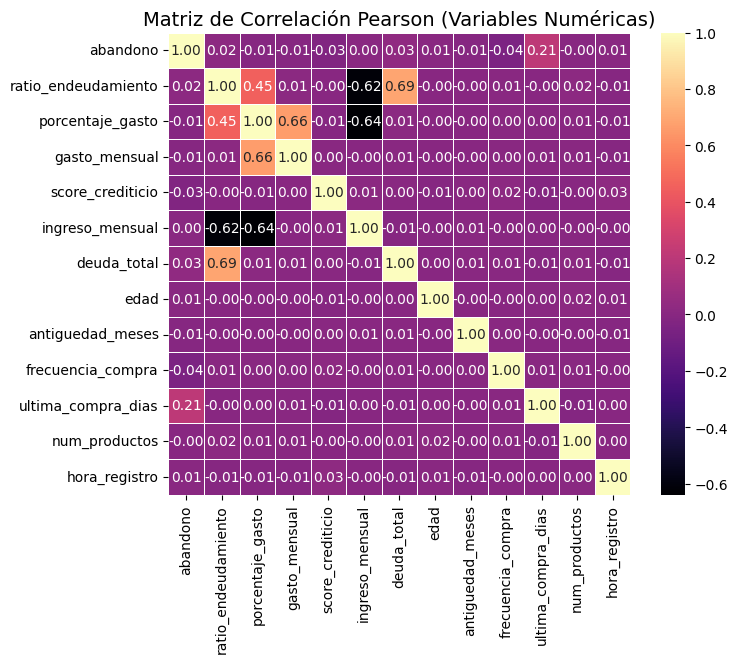

In [19]:
# heatmap matriz de correlación
plt.figure(figsize=(8, 6))  # tamaño de la figura
sns.heatmap(
    correlaciones,
    annot=True,       # mostrar los valores
    cmap="magma",     # paleta de colores
    fmt=".2f",        # formato decimal
    square=True,      # cuadrados uniformes
    linewidths=0.5    # líneas entre celdas
)
plt.title("Matriz de Correlación Pearson (Variables Numéricas)", fontsize=14)
plt.show()

### Mejores variables predictoras para los modelos de clasificación

In [20]:
def seleccionar_mejores_predictores_clasificacion(dataframe, target, umbral=0.008):
    """
    Selecciona variables predictoras para clasificacion usando correlacion de Pearson.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Conjunto de datos con variables numericas.
    target : str
        Nombre de la variable objetivo.
    umbral : float, default=0.008
        Umbral minimo de correlacion (valor absoluto).

    Returns
    -------
    pd.DataFrame
        Tabla con variables y correlaciones ordenadas.
    """
    correlaciones = dataframe.corr(numeric_only=True)
    correlacion_objetivo = correlaciones[target].sort_values(ascending=False)
    correlacion_abs = correlacion_objetivo.abs()
    mask = (correlacion_abs >= umbral) & (correlacion_abs < 1.0)
    seleccion = correlacion_objetivo[mask].sort_values(ascending=False)
    salida = seleccion.reset_index()
    salida.columns = ["variable", "correlacion"]
    salida["correlacion_abs"] = salida["correlacion"].abs()
    return salida

mejores_predictores_clasif = seleccionar_mejores_predictores_clasificacion(
    data,
    target,
    umbral=0.008,
)
mejores_predictores_clasif.sort_values("correlacion_abs", ascending=False).round(4)

,variable,correlacion,correlacion_abs
0,ultima_compra_dias,0.2126,0.2126
13,uso_app,-0.1647,0.1647
12,tipo_plan,-0.0824,0.0824
11,frecuencia_compra,-0.0449,0.0449
1,deuda_total,0.0323,0.0323
10,score_crediticio,-0.0267,0.0267
2,ratio_endeudamiento,0.0198,0.0198
9,dia_semana_registro_Viernes,-0.0172,0.0172
8,region_Norte,-0.0163,0.0163
3,dia_semana_registro_Jueves,0.0127,0.0127
